# Experiments Notebook

This notebook is used for running experiments and testing different configurations of the neural network.

In [1]:
import sys
import torch
from pathlib import Path

# Get the current working directory and check where we are
print(f"Current working directory: {Path.cwd()}")

# If you're in the notebooks directory, go up one level
if Path.cwd().name == 'notebooks':
    sys.path.append(str(Path.cwd().parent))
else:
    # If you're in the project root, add current directory
    sys.path.append(str(Path.cwd()))

# Import necessary libraries

from src.layers.input import InputLayer;
from src.layers.dense import DenseLayer;

from src.losses.cross_entropy import Loss;
from src.optimizers.gradient_descent import GD;
from src.utils.data_loader import load_data;




Current working directory: /home/protim/Documents/basis/notebooks


In [2]:
# Define hyperparameters
hyperparams = {
    'input_units': 2,
    'hidden_units': 2,
    'output_units': 1

}

In [3]:
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_layer = InputLayer( hyperparams, name='input', device=device );
hidden_layer = DenseLayer( hyperparams, name='hidden', transfer='sigmoid', device=device );
output_layer = DenseLayer( hyperparams, name='output', transfer='sigmoid', device=device );

network = input_layer >> hidden_layer >> output_layer;

In [4]:
# Load XOR data
( train_data, train_labels ), ( test_data, test_labels ) = load_data( "xor", device=device );
print( f"Train data shape: {train_data.shape}, Train labels shape: {train_labels.shape}" );

Train data shape: torch.Size([4, 2]), Train labels shape: torch.Size([4, 1])


In [5]:
print( f"\nNumber of trainable parameters: {sum( p.numel() for p in network.trainable_parameters.values() )}" );
print( f"\nTrainable Parameters:" );
for name, param in network.trainable_parameters.items():
    print( f"{name}: {param.shape}" );

# print param values
print("\nInitial parameter values:");
for name, param in network.trainable_parameters.items():
    print(f"{name}: {param.data}")



Number of trainable parameters: 9

Trainable Parameters:
hidden: torch.Size([2, 1])
W_input_hidden_layer: torch.Size([2, 2])
W_hidden_output_layer: torch.Size([1, 2])
output: torch.Size([1, 1])

Initial parameter values:
hidden: tensor([[0.],
        [0.]], device='cuda:0')
W_input_hidden_layer: tensor([[ 0.1372,  1.5283],
        [-0.1217,  0.6004]], device='cuda:0')
W_hidden_output_layer: tensor([[ 0.1136, -0.0884]], device='cuda:0')
output: tensor([[0.]], device='cuda:0')


In [6]:
print("XOR Network Forward Pass:")
for i in range(train_data.shape[0]):
    input_tensor = train_data[i].unsqueeze(1) # Shape (2, 1)
    output = network.forward(input_tensor)
    print(f"Input: {train_data[i].tolist()} -> Output: {output['output'].squeeze().item():.4f}, Expected: {train_labels[i].item():.1f}")

XOR Network Forward Pass:
Input: [0.0, 0.0] -> Output: 0.5032, Expected: 0.0
Input: [0.0, 1.0] -> Output: 0.5091, Expected: 1.0
Input: [1.0, 0.0] -> Output: 0.5048, Expected: 1.0
Input: [1.0, 1.0] -> Output: 0.5102, Expected: 0.0


In [7]:
# 1. Instantiate Loss Function
bce_loss = Loss(name="binary_cross_entropy")

In [8]:
# 2. Compile the network (Optimizer and Learning Rate)
# Gradients are now averaged over the batch, so the effective step size is ~1/N
# of the old (summed-gradient) behaviour. Use a larger learning rate for XOR
# (4 samples) so it still escapes the sigmoid plateau within a few thousand epochs.
learning_rate = 7.0
network.compile(loss=bce_loss, optimizer_class=GD, learning_rate=learning_rate)

In [9]:
# 3. Train the Network
epochs = 300 # More epochs for XOR
import threading
# Start GPU monitoring in separate thread
print("\nStarting Training...")
network.train(train_data, train_labels, epochs=epochs, save_param_history=True)
print("Training Finished.")


Starting Training...
GPU Available: NVIDIA GeForce RTX 3080
Number of GPUs: 1
TensorBoard log directory created at: runs/nn_training_gpu_cuda/run_20260708_095544_d185d479
Epoch 1/300, Loss: 0.693021, Time: 120.1ms


/home/protim/Documents/basis/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-07-08 09:55:46 466892:466892 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-08 09:55:47 466892:466892 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-08 09:55:49 466892:466892 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-08 09:55:49 466892:466892 ActivityProfilerController.cpp:455] profiler_stop


Epoch 100/300, Loss: 0.054452, Time: 11.3ms
Epoch 200/300, Loss: 0.011122, Time: 13.4ms
Epoch 300/300, Loss: 0.006102, Time: 30.1ms

Peak GPU memory usage: 21.6 MB
Total training time: 12.77 seconds
Average time per epoch: 14.75 ms

Profiler trace saved to: runs/nn_training_gpu_cuda/profiler
Training Finished.


In [10]:
# Load TensorBoard extension
%load_ext tensorboard

# Display TensorBoard in the notebook
%tensorboard --logdir ../notebooks/runs/

## Training Metrics (Inline Charts)

The cells below read the TensorBoard event files directly and render all metrics as matplotlib figures, so the charts are visible in GitHub and static notebook viewers.

In [11]:
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 10})

from src.utils.plot_utils import load_latest_run, load_all_runs

RUNS_DIR = "../notebooks/runs/nn_training_gpu_cuda"

# Load the most recent run
run_data, run_path = load_latest_run(RUNS_DIR)
run_name = run_path.split("/")[-1]

print(f"Loaded run: {run_name}")
print(f"Available tags ({len(run_data)}):")
for tag in sorted(run_data):
    n = len(run_data[tag]["steps"])
    print(f"  {tag}  ({n} points)")

Loaded run: run_20260708_095544_d185d479
Available tags (15):
  GPU/memory_allocated_mb  (61 points)
  GPU/memory_cached_mb  (30 points)
  GPU/memory_free_mb  (31 points)
  GPU/memory_reserved_mb  (31 points)
  GPU/memory_total_mb  (31 points)
  GPU/memory_utilization_percent  (31 points)
  GPU/temperature_celsius  (31 points)
  GPU/utilization_percent  (31 points)
  Loss/epoch  (300 points)
  System/cpu_percent  (31 points)
  System/memory_percent  (31 points)
  Timing/backward_pass_ms  (12 points)
  Timing/epoch_time_ms  (300 points)
  Timing/forward_pass_ms  (12 points)
  Timing/samples_per_second  (300 points)


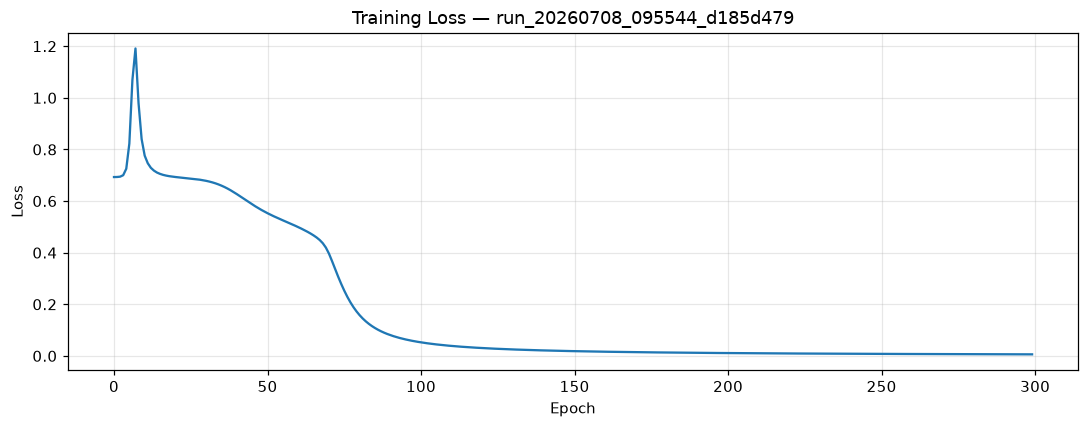

In [12]:
from src.utils.plot_utils import plot_loss
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
plot_loss(run_data, ax=ax, title=f"Training Loss — {run_name}")
plt.tight_layout()
plt.show()

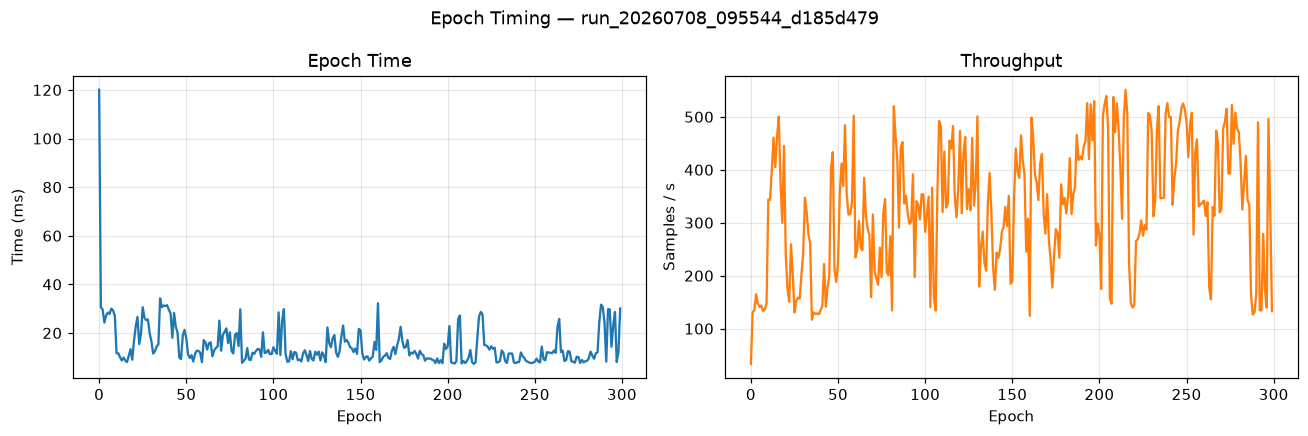

In [13]:
from src.utils.plot_utils import plot_timing

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_timing(run_data, axes=axes)
fig.suptitle(f"Epoch Timing — {run_name}", fontsize=12)
plt.tight_layout()
plt.show()

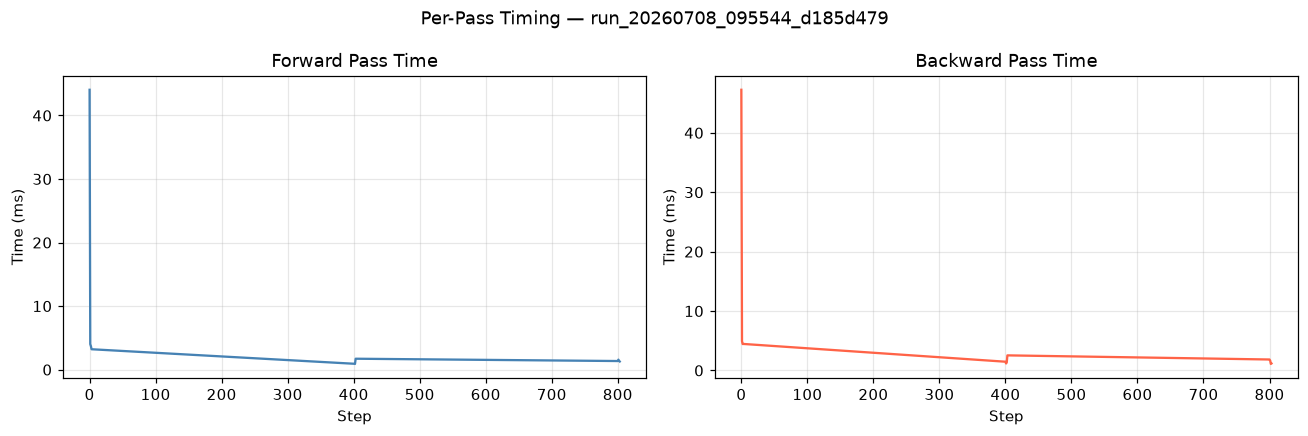

In [14]:
from src.utils.plot_utils import plot_pass_timing

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pass_timing(run_data, axes=axes)
fig.suptitle(f"Per-Pass Timing — {run_name}", fontsize=12)
plt.tight_layout()
plt.show()

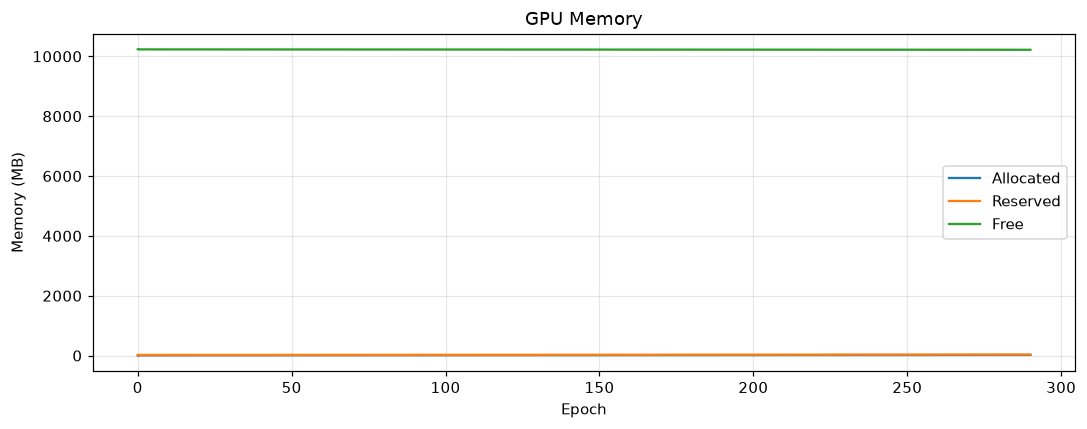

In [15]:
from src.utils.plot_utils import plot_gpu_memory

gpu_tags = [t for t in run_data if t.startswith("GPU/")]
if gpu_tags:
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_gpu_memory(run_data, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("No GPU metrics recorded (CPU-only run).")

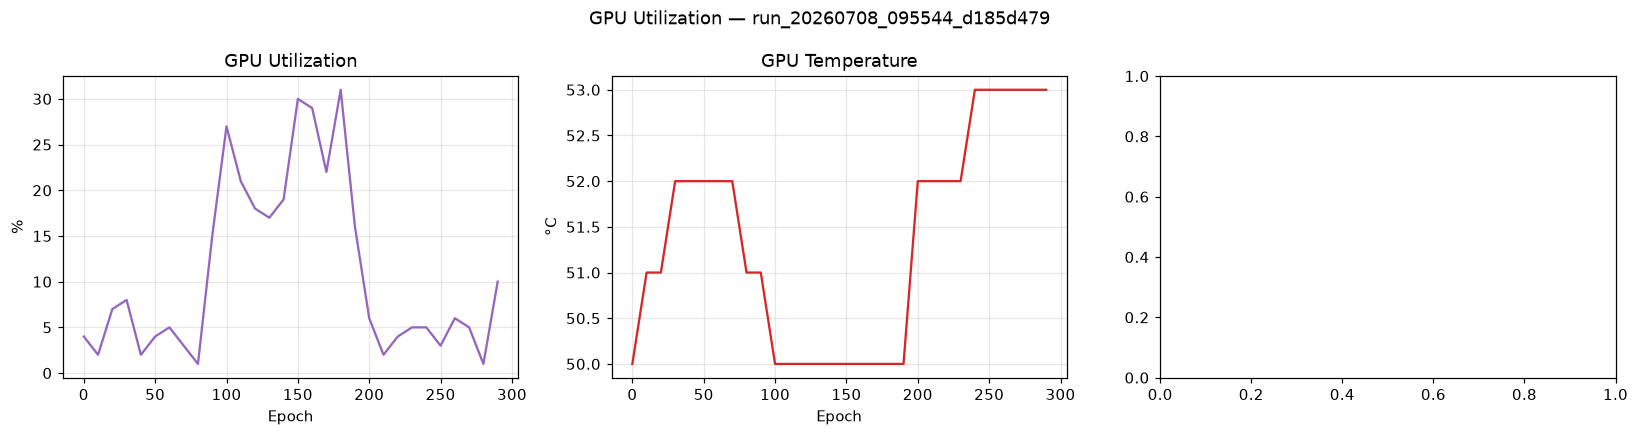

In [16]:
from src.utils.plot_utils import plot_gpu_utilization

if gpu_tags:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plot_gpu_utilization(run_data, axes=axes)
    fig.suptitle(f"GPU Utilization — {run_name}", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No GPU metrics recorded (CPU-only run).")

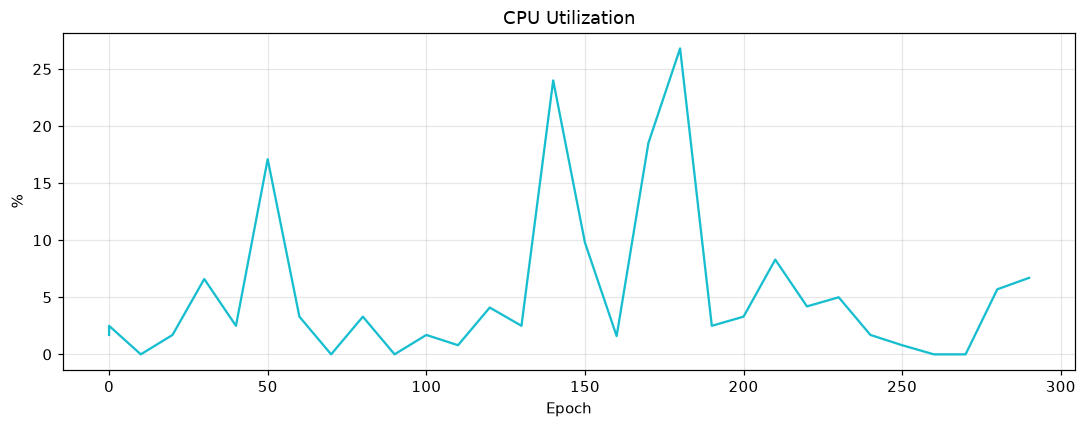

In [17]:
from src.utils.plot_utils import plot_system

fig, ax = plt.subplots(figsize=(10, 4))
plot_system(run_data, ax=ax)
plt.tight_layout()
plt.show()